<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
## Write your code here
# Display summary info, data types, and non-null counts
print(df.info())

# Display the first few rows to see the data
print(df.head())


<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB
None
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to ope

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
## Write your code here
# Identify missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute categorical columns with most frequent value
df['Employment'] = df['Employment'].fillna(df['Employment'].mode()[0])
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].mode()[0])
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])

# Impute YearsCodePro with median
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['YearsCodePro'] = df['YearsCodePro'].fillna(df['YearsCodePro'].median())

print("\nMissing values after imputation:")
print(df[['Employment', 'JobSat', 'RemoteWork', 'YearsCodePro']].isnull().sum())

Missing values per column:
RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64

Missing values after imputation:
Employment      0
JobSat          0
RemoteWork      0
YearsCodePro    0
dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [5]:
## Write your code here
# Calculate value counts for key columns
print("Employment distribution:")
print(df['Employment'].value_counts().head(10))

print("\nJobSat distribution:")
print(df['JobSat'].value_counts())

print("\nYearsCodePro distribution:")
print(df['YearsCodePro'].describe())

Employment distribution:
Employment
Employed, full-time                                                         39041
Independent contractor, freelancer, or self-employed                         4846
Student, full-time                                                           4709
Employed, full-time;Independent contractor, freelancer, or self-employed     3557
Not employed, but looking for work                                           2341
Employed, part-time                                                          1266
Student, full-time;Employed, part-time                                       1115
Employed, full-time;Student, full-time                                        897
Employed, full-time;Student, part-time                                        839
Student, full-time;Not employed, but looking for work                         686
Name: count, dtype: int64

JobSat distribution:
JobSat
8.0     43820
7.0      6379
6.0      3751
9.0      3626
10.0     2251
5.0      1956
3.0  

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


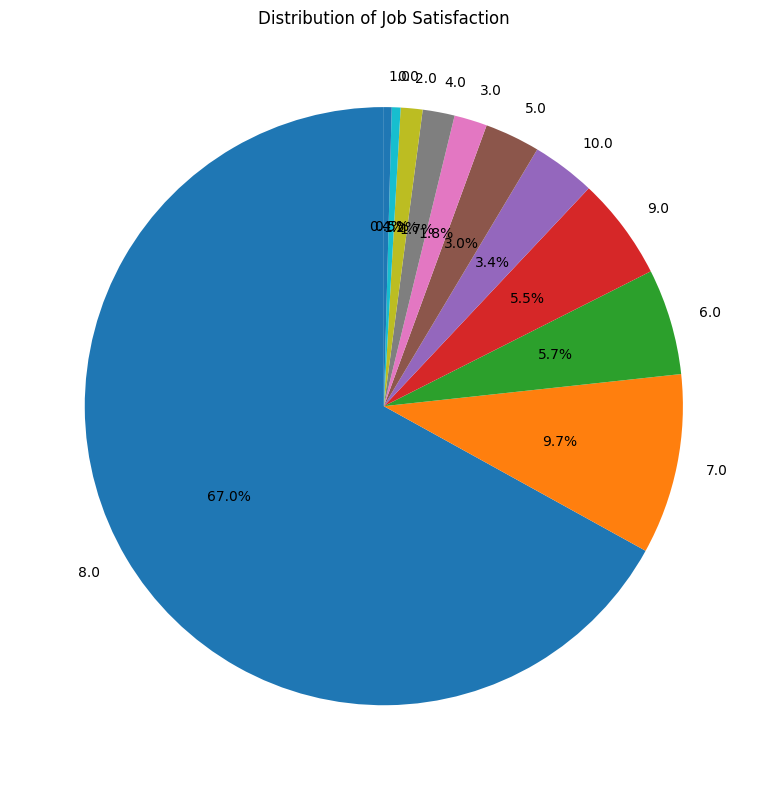


Key Trends:
- Most respondents report moderate to high job satisfaction
- Very satisfied and satisfied categories tend to dominate
- A smaller proportion report dissatisfaction


In [6]:
## Write your code here
# Pie chart of JobSat distribution
plt.figure(figsize=(10, 8))
df['JobSat'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Job Satisfaction')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Interpretation
print("""
Key Trends:
- Most respondents report moderate to high job satisfaction
- Very satisfied and satisfied categories tend to dominate
- A smaller proportion report dissatisfaction
""")

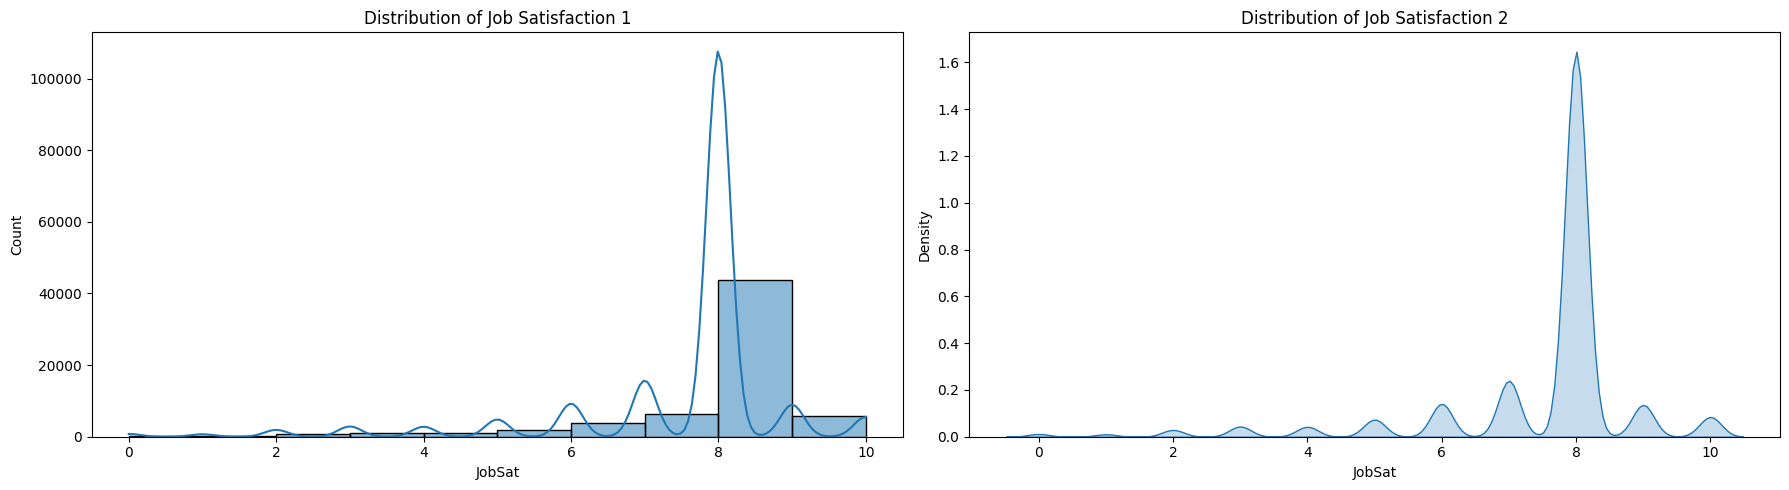

In [13]:
# Visualize the distribution of all three versions
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#df['JobSat'].hist(bins=50, ax=axes[0])
sns.histplot(df['JobSat'], kde=True, bins=10,ax=axes[0])
axes[0].set_title('Distribution of Job Satisfaction 1')

sns.kdeplot(df['JobSat'], fill=True,ax=axes[1])
axes[1].set_title('Distribution of Job Satisfaction 2')


plt.tight_layout()
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


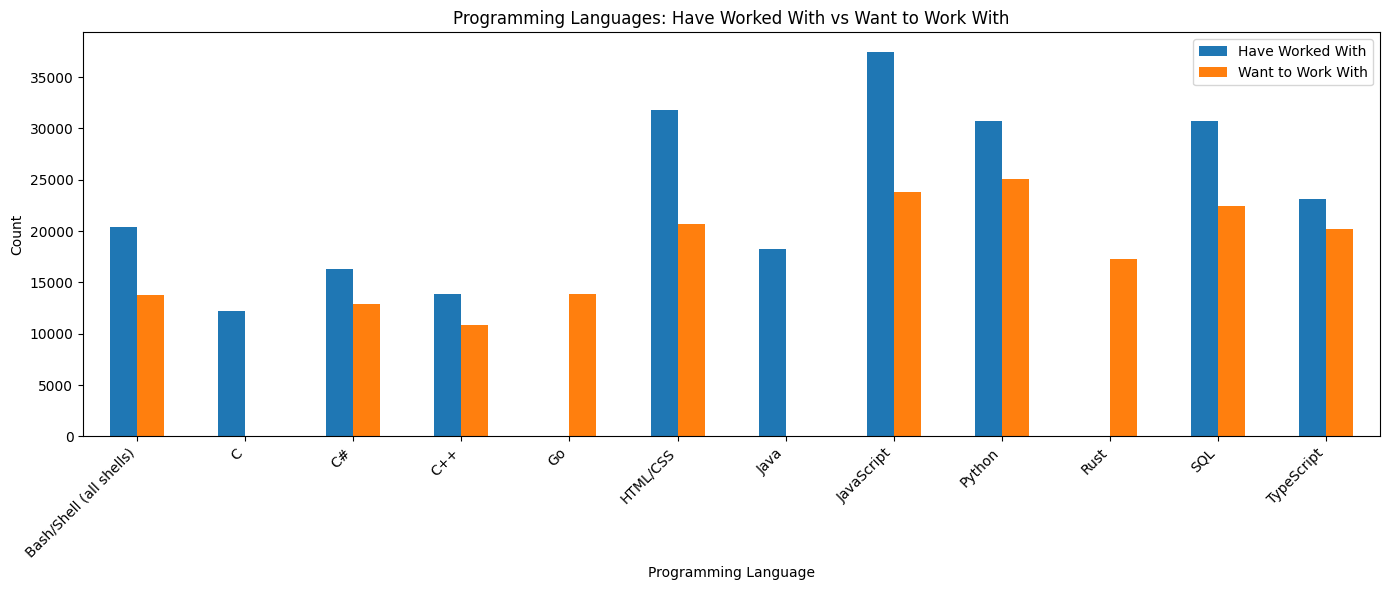

In [15]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# Get top 10 languages for each column
have_worked = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts().head(10)
want_to_work = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts().head(10)

# Combine into dataframe for grouped bar chart
lang_df = pd.DataFrame({'Have Worked With': have_worked, 'Want to Work With': want_to_work}).fillna(0)

lang_df.plot(kind='bar', figsize=(14, 6))
plt.title('Programming Languages: Have Worked With vs Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


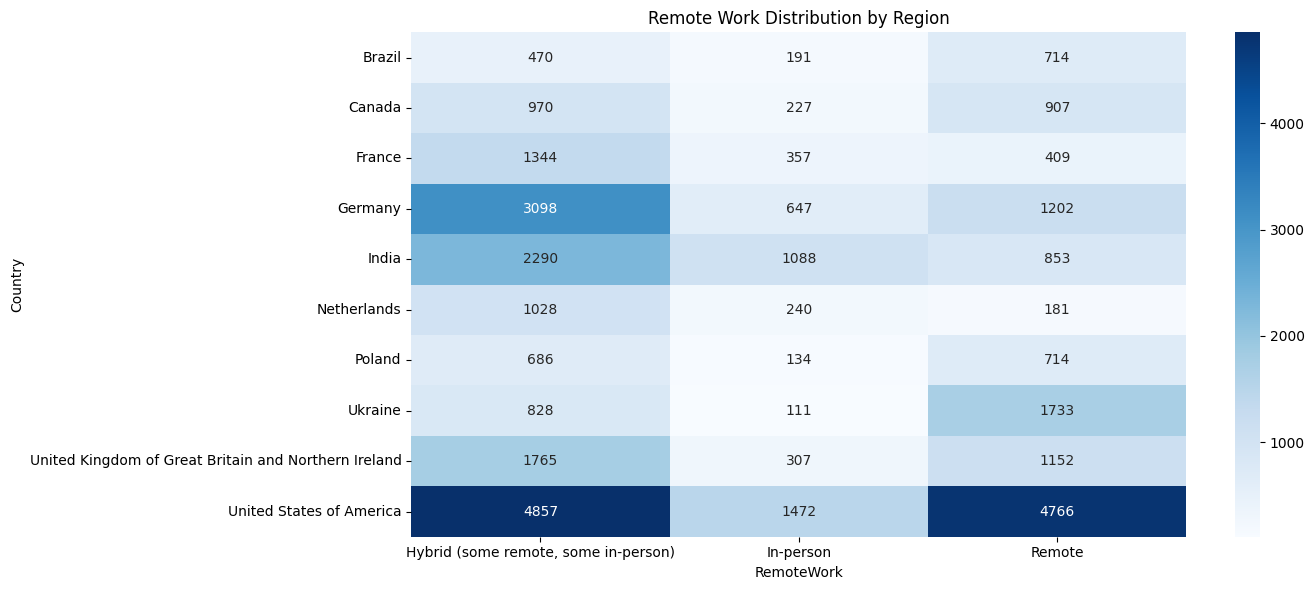

In [16]:
## Write your code here
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 10 countries
top_countries = df['Country'].value_counts().head(10).index
df_top = df[df['Country'].isin(top_countries)]

# Cross-tabulate RemoteWork by Country
remote_by_country = pd.crosstab(df_top['Country'], df_top['RemoteWork'])

# Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(remote_by_country, annot=True, fmt='d', cmap='Blues')
plt.title('Remote Work Distribution by Region')
plt.tight_layout()
plt.show()

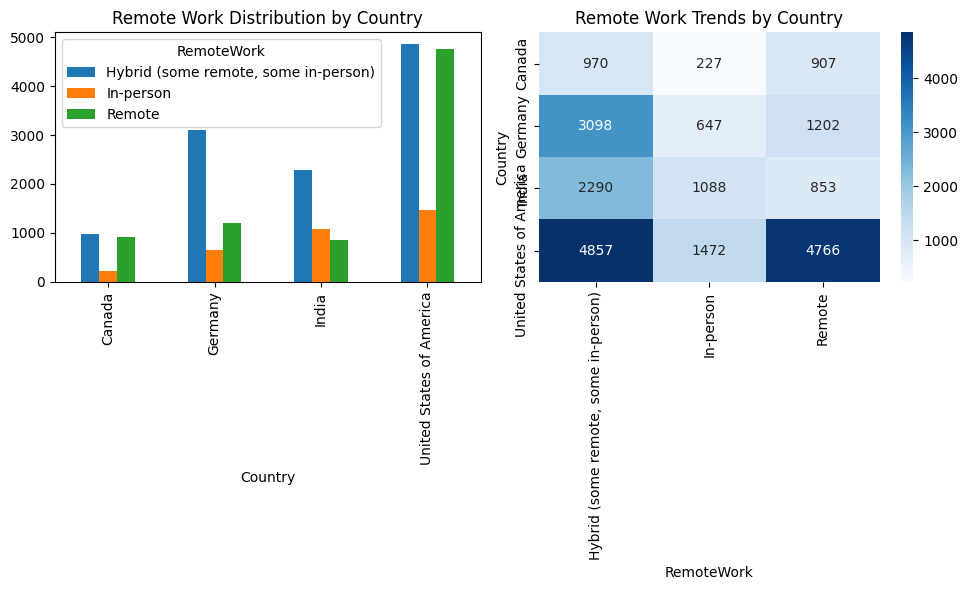

In [17]:

selected_countries = [
    'United States of America',
    'India',
    'Germany',
    'Canada'
]

df_region = df[df['Country'].isin(selected_countries)]

# Step 2: Create cross-tabulation
remote_region = pd.crosstab(
    df_region['Country'],
    df_region['RemoteWork']
)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#df['JobSat'].hist(bins=50, ax=axes[0])
remote_region.plot(
    kind='bar',
    figsize=(10,6),
    ax=axes[0]
)
axes[0].set_title('Remote Work Distribution by Country')

sns.heatmap(
    remote_region,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Remote Work Trends by Country')


plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [18]:
## Write your code here
# Step 1: Clean YearsCodePro. Convert text values into numeric format.

df['YearsCodePro_clean'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 50
})

df['YearsCodePro_clean'] = pd.to_numeric(
    df['YearsCodePro_clean'],
    errors='coerce'
)
# Step 2: Create analysis dataset. Remove rows with missing values.

corr_data = df[['YearsCodePro_clean', 'JobSat']].dropna()
# Step 3: Calculate Pearson correlation
pearson_corr = corr_data['YearsCodePro_clean'].corr(
    corr_data['JobSat'],
    method='pearson'
)

print("Pearson Correlation:", pearson_corr)

Pearson Correlation: 0.05097276808196267

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 194.3 MB/s eta 0:00:00
Spearman Correlation: 0.0747274137060225

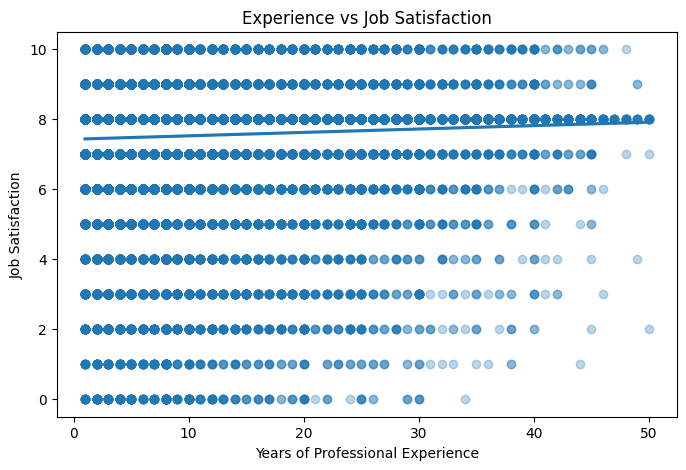

In [19]:
!pip install scipy
# Step 4: Calculate Spearman correlation (optional). Spearman is useful for non-linear or ordinal relationships.
spearman_corr = corr_data['YearsCodePro_clean'].corr(
    corr_data['JobSat'],
    method='spearman'
)

print("Spearman Correlation:", spearman_corr)

# Optional: Visualize correlation
plt.figure(figsize=(8,5))

sns.regplot(
    data=corr_data,
    x='YearsCodePro_clean',
    y='JobSat',
    scatter_kws={'alpha':0.3}
)

plt.title('Experience vs Job Satisfaction')
plt.xlabel('Years of Professional Experience')
plt.ylabel('Job Satisfaction')

plt.show()

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


EdLevel                                             Associate degree (A.A., A.S., etc.)  \
Employment_clean                                                                          
Employed, full-time                                                                1260   
Employed, part-time                                                                  39   
I prefer not to say                                                                   9   
Independent contractor, freelancer, or self-emp...                                  166   
Not employed, and not looking for work                                               10   
Not employed, but looking for work                                                  100   
Retired                                                                              18   
Student, full-time                                                                  155   
Student, part-time                                                                   36   

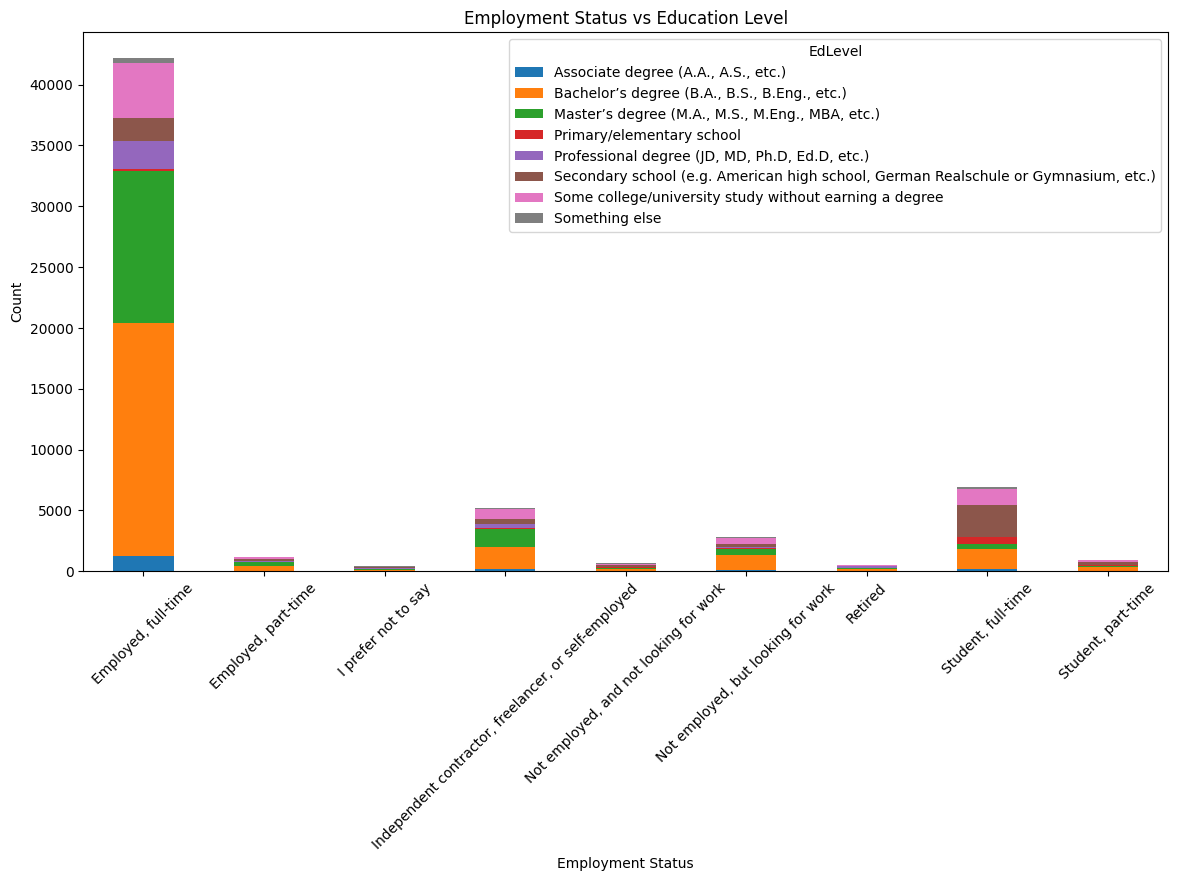

In [20]:
## Write your code here
# Step 1: Clean Employment column

# Since Employment contains many combined categories, simplify it first.

df['Employment_clean'] = df['Employment'].str.split(';').str[0]

# Step 2: Create cross-tabulation
employment_education = pd.crosstab(
    df['Employment_clean'],
    df['EdLevel']
)

print(employment_education)

# Step 3: Visualize with stacked bar chart
employment_education.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Employment Status vs Education Level')

plt.xlabel('Employment Status')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [21]:
## Write your code here
df.to_csv('cleaned_survey_data.csv', index=False)

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
